# ARIMA: model experiment



## 0. Setup & configuration

In [ ]:
import importlib.util, sys, subprocess
if importlib.util.find_spec("mlflow") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "mlflow"], check=True)
    print("mlflow installed.")
else:
    print("mlflow already present.")

mlflow installed.


In [ ]:
import os, sys, json, time, tempfile, warnings
from collections import namedtuple, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import mlflow

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Kaggle WMAE: holiday weeks weighted 5x
HOLIDAY_WEIGHT, NON_HOLIDAY_WEIGHT = 5.0, 1.0

FREQ                 = "W-FRI"   # Walmart weekly grid ends on Fridays
CV_FOLDS             = 3
CV_VALIDATION_WEEKS  = 8         # each expanding-window fold validates on 8 weeks
FINAL_HOLDOUT_WEEKS  = 12        # last 12 weeks reserved, scored once for the winner
MIN_TRAIN_WEEKS      = 40        # a fold's train window must be at least this long
REP_SERIES_PER_TIER  = 10        # 10 low + 10 medium + 10 high = 30 representative series
FORECAST_CAP_FACTOR  = 5.0       # a forecast may not exceed this x the series' own historical max
RUN_FULL_SUBMISSION  = True      # fit all ~3,300 series once and write the Kaggle submission

print("Setup complete.")

Setup complete.


In [ ]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
    DATA_DIR = Path("/content/drive/MyDrive/ML_FINAL_PROJECT/data")
except ModuleNotFoundError:
    DATA_DIR = Path("data")

def _read(name):
    for cand in (DATA_DIR / f"{name}.csv", DATA_DIR / f"{name}.csv.zip"):
        if cand.exists():
            return pd.read_csv(cand)
    raise FileNotFoundError(f"{name}.csv[.zip] not found in {DATA_DIR}")

train    = _read("train")
test     = _read("test")
features = _read("features")
stores   = _read("stores")
print("train", train.shape, "| test", test.shape)

Mounted at /content/drive
train (421570, 5) | test (115064, 4)


In [ ]:
import getpass
DAGSHUB_REPO     = "ZukaCS/ML_FINAL_PROJECT"
DAGSHUB_USERNAME = "dgrig23"
mlflow.set_tracking_uri(f"https://dagshub.com/{DAGSHUB_REPO}.mlflow")
os.environ["MLFLOW_TRACKING_USERNAME"] = DAGSHUB_USERNAME
os.environ["MLFLOW_TRACKING_PASSWORD"] = getpass.getpass("DagsHub token: ")
mlflow.set_experiment("ARIMA_Training")
print("tracking:", mlflow.get_tracking_uri())

DagsHub token: ··········
tracking: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow


## 1. Clean & merge


In [ ]:
def clean_and_merge(train_df):
    df = (train_df
          .merge(stores,   on="Store", how="left")
          .merge(features, on=["Store", "Date", "IsHoliday"], how="left"))
    df["Date"] = pd.to_datetime(df["Date"])
    df["Weekly_Sales"] = df["Weekly_Sales"].clip(lower=0)
    df["IsHoliday"] = df["IsHoliday"].astype(float)
    return df.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)

merged_train = clean_and_merge(train)
print("merged_train", merged_train.shape)

merged_train (421570, 16)


## 2. Representative series selector

Local models fit one model per series; scoring on all ~3,300 is expensive. We select a small
**stratified** set (by volume tier)
The winner is then confirmed on all series in the Final stage (Section 10).

In [ ]:
def select_representative_series(df, n_per_tier=REP_SERIES_PER_TIER, seed=RANDOM_SEED):
    stats = (df.groupby(["Store", "Dept"])["Weekly_Sales"]
               .agg(total_sales="sum", n_weeks="size").reset_index())
    complete = stats[stats["n_weeks"] == int(stats["n_weeks"].max())].copy()
    try:
        complete["volume_tier"] = pd.qcut(complete["total_sales"], 3,
                                           labels=["low", "medium", "high"])
    except ValueError:
        complete["volume_tier"] = pd.qcut(complete["total_sales"].rank(method="first"), 3,
                                           labels=["low", "medium", "high"])
    picks = pd.concat([g.sample(min(n_per_tier, len(g)), random_state=seed)
                       for _, g in complete.groupby("volume_tier", observed=True)],
                      ignore_index=True)
    return picks

selected = select_representative_series(merged_train)
selected_keys = list(zip(selected["Store"], selected["Dept"]))
print(f"{len(selected_keys)} representative series "
      f"({selected['volume_tier'].value_counts().to_dict()})")
selected[["Store", "Dept", "total_sales", "n_weeks", "volume_tier"]]

30 representative series ({'low': 10, 'medium': 10, 'high': 10})


,Store,Dept,total_sales,n_weeks,volume_tier
0,15,50,323490.71,143,low
1,35,83,357099.15,143,low
2,28,52,378310.35,143,low
3,33,74,51952.16,143,low
4,32,52,359356.63,143,low
5,3,21,177967.74,143,low
6,28,31,369504.14,143,low
7,30,98,458605.96,143,low
8,37,87,145869.61,143,low
9,7,31,257336.97,143,low


## 3. Weighted MAE (pooled)

In [ ]:
def weighted_mae(y_true, y_pred, is_holiday):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    weights = np.where(np.asarray(is_holiday, dtype=bool), HOLIDAY_WEIGHT, NON_HOLIDAY_WEIGHT)
    return float(np.average(np.abs(y_true - y_pred), weights=weights))


def cap_forecast(fc, hist_max, factor=FORECAST_CAP_FACTOR):
    fc = np.asarray(fc, dtype=float)
    cap = max(float(hist_max), 1.0) * factor
    if not np.all(np.isfinite(fc)) or float(np.nanmax(fc)) > cap:
        return None
    return np.clip(fc, 0.0, cap)

## 4. Series preprocessor + validation splits


In [ ]:
class ArimaSeriesPreprocessor:
    """One Store-Dept on the strict weekly grid. Raises on gaps; never interpolates."""
    def __init__(self, exog_cols=None):
        self.exog_cols = list(exog_cols or [])

    def build(self, df, store, dept):
        s = (df[(df["Store"] == store) & (df["Dept"] == dept)]
             .sort_values("Date").set_index("Date").asfreq(FREQ))
        if s["Weekly_Sales"].isna().any():
            raise ValueError(f"Store {store} Dept {dept} has gaps - not a complete series.")
        s["IsHoliday"] = s["IsHoliday"].fillna(0).astype(float)
        for c in self.exog_cols:
            if c in s.columns:
                s[c] = s[c].ffill().bfill()
        return s.reset_index()


Split = namedtuple("Split", ["train", "validation"])

def chronological_holdout(series_df, validation_weeks):
    cut = len(series_df) - validation_weeks
    return Split(series_df.iloc[:cut].copy(), series_df.iloc[cut:].copy())

def expanding_window_splits(series_df, n_splits, validation_weeks):
    total, splits = len(series_df), []
    for i in range(n_splits):
        val_end   = total - (n_splits - 1 - i) * validation_weeks
        val_start = val_end - validation_weeks
        if val_start < MIN_TRAIN_WEEKS:
            raise ValueError("series too short for CV")
        splits.append(Split(series_df.iloc[:val_start].copy(),
                            series_df.iloc[val_start:val_end].copy()))
    return splits

## 5. OrderCalibrator + ArimaForecaster



In [ ]:
class OrderCalibrator:
    """Pick one (p,d,q) per series by AICc on a single window (no leakage)."""
    def __init__(self, order_grid):
        self.order_grid = order_grid

    def calibrate(self, values, exog=None):
        best_order, best_score = None, np.inf
        for order in self.order_grid:
            try:
                fitted = ARIMA(values, exog=exog, order=order,
                               enforce_stationarity=True,
                               enforce_invertibility=True).fit()
            except Exception:
                continue
            if np.isfinite(fitted.aicc) and fitted.aicc < best_score:
                best_order, best_score = order, fitted.aicc
        return best_order, best_score


class ArimaForecaster:
    """Fit/predict one series for an ALREADY-chosen fixed order."""
    def __init__(self, order, exog_cols=None):
        self.order = order
        self.exog_cols = list(exog_cols or [])
        self.res = None

    def fit(self, train_df, value_col="Weekly_Sales"):
        exog = train_df[self.exog_cols].values if self.exog_cols else None
        self.res = ARIMA(train_df[value_col].values, exog=exog, order=self.order,
                         enforce_stationarity=True, enforce_invertibility=True).fit()
        return self

    def predict(self, future_df):
        exog = future_df[self.exog_cols].values if self.exog_cols else None
        return np.asarray(self.res.forecast(steps=len(future_df), exog=exog))

## 6. Trial runner

Per fold, predictions are **pooled across all series** and WMAE is computed once on the pool.
Order is calibrated once per series from `cv_splits[0].train`; the holdout is only touched when
`do_holdout=True`.

In [ ]:
def run_arima_trial(keys, order_grid, exog_cols, label,
                    do_cv=True, do_holdout=False, verbose=True):
    pre = ArimaSeriesPreprocessor(exog_cols=exog_cols)
    cal = OrderCalibrator(order_grid)
    fold_rows, holdout_rows, orders = defaultdict(list), [], []
    fit_s = pred_s = 0.0

    for store, dept in keys:
        try:
            sdf = pre.build(merged_train, store, dept)
        except ValueError:
            continue
        try:
            hold = chronological_holdout(sdf, FINAL_HOLDOUT_WEEKS)
            cvs  = expanding_window_splits(hold.train, CV_FOLDS, CV_VALIDATION_WEEKS)
        except ValueError:
            continue

        cal_exog = cvs[0].train[exog_cols].values if exog_cols else None
        order, aicc = cal.calibrate(cvs[0].train["Weekly_Sales"].values, exog=cal_exog)
        if order is None:
            continue
        orders.append({"Store": store, "Dept": dept, "order": order, "aicc": aicc})

        if do_cv:
            for fi, fold in enumerate(cvs):
                fc = ArimaForecaster(order, exog_cols)
                t = time.perf_counter()
                try:
                    fc.fit(fold.train)
                except Exception:
                    continue
                fit_s += time.perf_counter() - t
                t = time.perf_counter(); yhat = fc.predict(fold.validation)
                pred_s += time.perf_counter() - t
                yhat = cap_forecast(yhat, fold.train["Weekly_Sales"].max())
                if yhat is None:
                    yhat = np.full(len(fold.validation), float(fold.train["Weekly_Sales"].median()))
                fold_rows[fi].append(pd.DataFrame({
                    "Store": store, "Dept": dept, "Date": fold.validation["Date"].values,
                    "actual": fold.validation["Weekly_Sales"].values, "prediction": yhat,
                    "IsHoliday": fold.validation["IsHoliday"].values}))

        if do_holdout:
            fc = ArimaForecaster(order, exog_cols)
            t = time.perf_counter()
            try:
                fc.fit(hold.train)
            except Exception:
                continue
            fit_s += time.perf_counter() - t
            t = time.perf_counter(); yhat = fc.predict(hold.validation)
            pred_s += time.perf_counter() - t
            yhat = cap_forecast(yhat, hold.train["Weekly_Sales"].max())
            if yhat is None:
                yhat = np.full(len(hold.validation), float(hold.train["Weekly_Sales"].median()))
            holdout_rows.append(pd.DataFrame({
                "Store": store, "Dept": dept, "Date": hold.validation["Date"].values,
                "actual": hold.validation["Weekly_Sales"].values, "prediction": yhat,
                "IsHoliday": hold.validation["IsHoliday"].values}))

    res = {"label": label, "exog_cols": exog_cols, "order_grid_size": len(order_grid),
           "fit_seconds": fit_s, "predict_seconds": pred_s,
           "series_used": len(orders), "series_count": len(keys),
           "orders_used": pd.DataFrame(orders)}

    if do_cv:
        fold_wmaes = []
        for fi in sorted(fold_rows):
            pooled = pd.concat(fold_rows[fi], ignore_index=True)
            fold_wmaes.append(weighted_mae(pooled["actual"], pooled["prediction"],
                                           pooled["IsHoliday"]))
        res["cv_wmae_mean"] = float(np.mean(fold_wmaes))
        res["cv_wmae_std"]  = float(np.std(fold_wmaes))
        res["fold_wmaes"]   = fold_wmaes

    if do_holdout and holdout_rows:
        ph = pd.concat(holdout_rows, ignore_index=True)
        res["holdout_wmae"] = weighted_mae(ph["actual"], ph["prediction"], ph["IsHoliday"])
        res["holdout_mae"]  = float(np.mean(np.abs(ph["actual"] - ph["prediction"])))
        res["holdout_rmse"] = float(np.sqrt(np.mean((ph["actual"] - ph["prediction"]) ** 2)))
        res["pooled_holdout_predictions"] = ph

    if verbose:
        bits = []
        if do_cv:                       bits.append(f"cv_wmae={res['cv_wmae_mean']:,.1f}")
        if do_holdout and holdout_rows: bits.append(f"holdout_wmae={res['holdout_wmae']:,.1f}")
        print(f"[{label}] " + ", ".join(bits) +
              f", fit={fit_s:.1f}s, series={res['series_used']}/{len(keys)}")
    return res

## 7. Order grids + timing probe



In [ ]:
BASE_ORDER_GRID = [(p, d, q) for p in (0, 1, 2) for d in (0, 1) for q in (0, 1, 2)]
WIDE_ORDER_GRID = [(p, d, q) for p in (0, 1, 2, 3) for d in (0, 1)
                   for q in (0, 1, 2, 3) if not (p == 0 and q == 0)]
print(f"Base grid: {len(BASE_ORDER_GRID)} combos/series (once)")
print(f"Wide grid: {len(WIDE_ORDER_GRID)} combos/series (once)")

t0 = time.perf_counter()
_probe = run_arima_trial(selected_keys[:3], BASE_ORDER_GRID, [], "probe", verbose=False)
per_series = (time.perf_counter() - t0) / 3
print(f"~{per_series:.2f}s per series (calibration + {CV_FOLDS} CV folds)")
print(f"Est. one full trial ({len(selected_keys)} series): ~{per_series*len(selected_keys)/60:.1f} min")

Base grid: 18 combos/series (once)
Wide grid: 30 combos/series (once)
~4.96s per series (calibration + 3 CV folds)
Est. one full trial (30 series): ~2.5 min


## 8. Stage: `ARIMA_Preprocessing` + `ARIMA_Feature_Selection`



In [ ]:
with mlflow.start_run(run_name="ARIMA_Preprocessing"):
    mlflow.set_tag("stage", "Preprocessing")
    mlflow.log_params({
        "series_unit": "Store_x_Dept_weekly",
        "reindex_freq": FREQ,
        "clip_negatives": True,
        "interpolation": "none (complete series only)",
        "target_transform": "none (raw sales)",
        "evaluation_scope": "stratified_representative_series",
        "series_per_tier": REP_SERIES_PER_TIER,
    })
    mlflow.log_metrics({
        "n_representative_series": len(selected_keys),
        "cv_folds": CV_FOLDS,
        "cv_validation_weeks": CV_VALIDATION_WEEKS,
        "final_holdout_weeks": FINAL_HOLDOUT_WEEKS,
    })

with mlflow.start_run(run_name="ARIMA_Feature_Selection"):
    mlflow.set_tag("stage", "Feature_Selection")
    mlflow.log_params({
        "target_columns_used": json.dumps(["Store", "Dept", "Date", "Weekly_Sales"]),
        "selected_exog_covariates": "compared in CV: none / IsHoliday / economic",
        "seasonal_terms": "none (pure ARIMA; 52-week cycle is out of reach -> see SARIMA)",
    })
print("preprocessing + feature-selection stages logged")

🏃 View run ARIMA_Preprocessing at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/8/runs/4df28caf14324e2eac19754143247971
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/8
🏃 View run ARIMA_Feature_Selection at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/8/runs/b0adbe9268994fe0b2e65d7587a27494
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/8
preprocessing + feature-selection stages logged


## 9. Stage: `ARIMA_CV` - trials

One parent run, one nested child per trial:

- **A** - no exog (pure ARIMA baseline)
- **B** - `IsHoliday` only
- **C** - full economic ARIMAX (`IsHoliday, Temperature, Fuel_Price, CPI, Unemployment`)
- **D** - no exog, **wider order grid** (does a bigger (p,d,q) search find a better order?)

All on the same 30 series.

In [ ]:
ECONOMIC_REGRESSORS = ["IsHoliday", "Temperature", "Fuel_Price", "CPI", "Unemployment"]
TRIAL_SPECS = [
    dict(label="A_no_exog",           exog=[],                  grid=BASE_ORDER_GRID),
    dict(label="B_isholiday",         exog=["IsHoliday"],       grid=BASE_ORDER_GRID),
    dict(label="C_economic_arimax",   exog=ECONOMIC_REGRESSORS, grid=BASE_ORDER_GRID),
    dict(label="D_no_exog_wide_grid", exog=[],                  grid=WIDE_ORDER_GRID),
]

trials = []
with mlflow.start_run(run_name="ARIMA_CV") as parent:
    mlflow.set_tag("stage", "CV")
    mlflow.log_params({"n_trials": len(TRIAL_SPECS), "cv_folds": CV_FOLDS,
                       "order_selection": "aicc_earliest_fold_only",
                       "metric": "pooled_wmae"})
    for spec in TRIAL_SPECS:
        with mlflow.start_run(run_name=f"ARIMA_CV_{spec['label']}", nested=True):
            t = run_arima_trial(selected_keys, spec["grid"], spec["exog"], spec["label"])
            t["grid"] = spec["grid"]
            mlflow.set_tag("stage", "CV")
            mlflow.log_params({"exog_cols": json.dumps(spec["exog"]),
                               "order_grid_size": len(spec["grid"])})
            mlflow.log_metrics({"cv_wmae_mean": t["cv_wmae_mean"],
                                "cv_wmae_std": t["cv_wmae_std"],
                                "fit_seconds": t["fit_seconds"],
                                "series_used": t["series_used"]})
            trials.append(t)

comparison = (pd.DataFrame([{"trial": t["label"], "exog_cols": t["exog_cols"],
                             "cv_wmae_mean": t["cv_wmae_mean"], "cv_wmae_std": t["cv_wmae_std"]}
                            for t in trials])
              .sort_values("cv_wmae_mean").reset_index(drop=True))
comparison

[A_no_exog] cv_wmae=1,881.7, fit=18.6s, series=30/30
🏃 View run ARIMA_CV_A_no_exog at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/8/runs/9f37bb6e363d45d2b8800f01a8e74de8
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/8
[B_isholiday] cv_wmae=1,882.1, fit=22.1s, series=30/30
🏃 View run ARIMA_CV_B_isholiday at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/8/runs/489fc1cadc974848b1ee8246bd75b15b
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/8
[C_economic_arimax] cv_wmae=1,966.4, fit=37.9s, series=30/30
🏃 View run ARIMA_CV_C_economic_arimax at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/8/runs/0b562f51fde349569469f16d42688c6d
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/8
[D_no_exog_wide_grid] cv_wmae=1,776.9, fit=22.8s, series=30/30
🏃 View run ARIMA_CV_D_no_exog_wide_grid at: https://dagshub.com/ZukaCS/ML_

,trial,exog_cols,cv_wmae_mean,cv_wmae_std
0,D_no_exog_wide_grid,[],1776.926771,295.754663
1,A_no_exog,[],1881.694194,337.644272
2,B_isholiday,[IsHoliday],1882.111529,302.630964
3,C_economic_arimax,"[IsHoliday, Temperature, Fuel_Price, CPI, Unem...",1966.433418,430.353422


In [ ]:
winner = min(trials, key=lambda t: t["cv_wmae_mean"])
print(f"Winner by pooled CV WMAE: {winner['label']} "
      f"(cv_wmae_mean={winner['cv_wmae_mean']:,.1f})")


_orders = winner["orders_used"]["order"]
FINAL_ORDER = tuple(_orders.mode().iloc[0]) if len(_orders) else (1, 1, 1)
print("Modal order for full-scale pipeline:", FINAL_ORDER)

Winner by pooled CV WMAE: D_no_exog_wide_grid (cv_wmae_mean=1,776.9)
Modal order for full-scale pipeline: (2, 1, 3)


## 10. Stage: `ARIMA_Final` (full scale)

Two holdout numbers, both logged:
- **`rep_holdout_wmae`** - the 30 complete representative series, comparable to SARIMA/Prophet.
- **`full_holdout_wmae`** - **all ~3,300 series**: each is fit once with the winning fixed order
  on train-minus-holdout, seasonal-naive department-median fallback for series too short/gappy.

Then the raw-`test` pipeline is logged as an MLflow pyfunc.

In [ ]:
class WalmartArimaPipeline(mlflow.pyfunc.PythonModel):

    def _setup(self, history, cfg):
        self.cfg = cfg
        history = history.copy()
        history["Date"] = pd.to_datetime(history["Date"])
        self.dept_median   = history.groupby("Dept")["Weekly_Sales"].median()
        self.global_median = float(history["Weekly_Sales"].median())
        self._groups = {k: v.sort_values("Date").set_index("Date")
                        for k, v in history.groupby(["Store", "Dept"])}

    def load_context(self, context):
        with open(context.artifacts["config"]) as fh:
            cfg = json.load(fh)
        self._setup(pd.read_csv(context.artifacts["history"]), cfg)

    def _forecast_series(self, store, dept, target_dates):
        s = self._groups.get((store, dept))
        if s is None:
            return None
        s = s.asfreq(FREQ)
        if s["Weekly_Sales"].notna().sum() < self.cfg["min_train_weeks"]:
            return None
        y = s["Weekly_Sales"].interpolate().ffill().bfill().values
        try:
            res = ARIMA(y, order=tuple(self.cfg["order"]),
                        enforce_stationarity=True, enforce_invertibility=True).fit()
        except Exception:
            return None
        last = s.index.max()
        steps = int((pd.Timestamp(max(target_dates)) - last).days // 7)
        if steps <= 0:
            return None
        fc = np.asarray(res.forecast(steps=steps), dtype=float)
        cap = max(float(np.nanmax(y)), 1.0) * float(self.cfg.get("cap_factor", 5.0))
        if not np.all(np.isfinite(fc)) or float(np.nanmax(fc)) > cap:
            return None   # unstable/explosive fit -> caller uses the dept-median fallback
        idx = pd.date_range(last + pd.Timedelta(weeks=1), periods=steps, freq=FREQ)
        return pd.Series(np.clip(fc, 0.0, cap), index=idx)

    def predict(self, context, model_input):
        df = model_input.copy()
        df["Date"] = pd.to_datetime(df["Date"])
        out = pd.Series(np.nan, index=df.index, dtype=float)
        for (store, dept), grp in df.groupby(["Store", "Dept"], sort=False):
            fallback = float(self.dept_median.get(dept, self.global_median))
            preds = self._forecast_series(store, dept, grp["Date"].tolist())
            vals = [float(preds.loc[d]) if (preds is not None and d in preds.index) else fallback
                    for d in grp["Date"]]
            out.loc[grp.index] = np.clip(vals, 0, None)
        return out.values

print("WalmartArimaPipeline defined")

WalmartArimaPipeline defined


/usr/local/lib/python3.12/dist-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [ ]:
def evaluate_full_scale(df, order, holdout_weeks=FINAL_HOLDOUT_WEEKS,
                        min_train_weeks=MIN_TRAIN_WEEKS, log_every=500):

    dept_median   = df.groupby("Dept")["Weekly_Sales"].median()
    global_median = float(df["Weekly_Sales"].median())
    rows, n_fit, n_fallback, n_skipped = [], 0, 0, 0
    groups = df.groupby(["Store", "Dept"], sort=False)
    t0 = time.perf_counter()
    for i, ((store, dept), g) in enumerate(groups, 1):
        s = g.sort_values("Date").set_index("Date").asfreq(FREQ)
        if len(s) <= holdout_weeks + 5:
            n_skipped += 1
            continue
        train_s, val_s = s.iloc[:-holdout_weeks], s.iloc[-holdout_weeks:]
        actual = val_s["Weekly_Sales"].values
        mask = ~np.isnan(actual)                      # drop holdout weeks the series is missing
        if mask.sum() == 0:
            n_skipped += 1
            continue
        is_holiday = val_s["IsHoliday"].fillna(0).values
        y = train_s["Weekly_Sales"].interpolate().ffill().bfill().values
        pred = None
        if np.isfinite(y).sum() >= min_train_weeks:
            try:
                res = ARIMA(y, order=order, enforce_stationarity=True,
                            enforce_invertibility=True).fit()
                pred = cap_forecast(res.forecast(steps=holdout_weeks), np.nanmax(y))
                if pred is not None:
                    n_fit += 1
            except Exception:
                pred = None
        if pred is None:
            pred = np.full(holdout_weeks, float(dept_median.get(dept, global_median)))
            n_fallback += 1
        rows.append(pd.DataFrame({"actual": actual[mask], "prediction": pred[mask],
                                  "IsHoliday": is_holiday[mask]}))
        if log_every and i % log_every == 0:
            print(f"  ...{i} series, {time.perf_counter()-t0:.0f}s elapsed", flush=True)

    pooled = pd.concat(rows, ignore_index=True)
    metrics = {
        "full_holdout_wmae": weighted_mae(pooled["actual"], pooled["prediction"], pooled["IsHoliday"]),
        "full_holdout_mae":  float(np.mean(np.abs(pooled["actual"] - pooled["prediction"]))),
        "full_holdout_rmse": float(np.sqrt(np.mean((pooled["actual"] - pooled["prediction"]) ** 2))),
    }
    counts = {"n_series_fit": n_fit, "n_series_fallback": n_fallback,
              "n_series_skipped": n_skipped, "n_pred_rows": len(pooled),
              "full_scale_seconds": time.perf_counter() - t0}
    return metrics, counts

print("evaluate_full_scale defined")

evaluate_full_scale defined


In [ ]:
run_name = f"ARIMA_Final__{winner['label']}__order{FINAL_ORDER}"
with mlflow.start_run(run_name=run_name) as final_run:
    mlflow.set_tag("stage", "Final")
    mlflow.log_params({
        "winner_trial": winner["label"],
        "winner_exog_cols": json.dumps(winner["exog_cols"]),
        "final_order": str(FINAL_ORDER),
        "order_selection_criterion": "aicc",
        "order_calibration_window": "earliest_cv_fold_training_only",
        "trials_compared": json.dumps([t["label"] for t in trials]),
        "final_scope": "all_series_full_scale",
        "enforce_stationarity_invertibility": True,
        "forecast_cap_factor": FORECAST_CAP_FACTOR,
    })

    # (a) representative holdout: 30 complete series, comparable to SARIMA/Prophet
    rep = run_arima_trial(selected_keys, winner["grid"], winner["exog_cols"],
                          winner["label"] + "_rep_holdout", do_cv=False, do_holdout=True)

    # (b) FULL-SCALE holdout: all ~3,300 series, winning order fit once each
    print(f"Full-scale holdout on ALL series with order {FINAL_ORDER}...", flush=True)
    full_metrics, full_counts = evaluate_full_scale(merged_train, FINAL_ORDER)

    mlflow.log_metrics({
        "rep_cv_wmae_mean": winner["cv_wmae_mean"], "rep_cv_wmae_std": winner["cv_wmae_std"],
        "rep_holdout_wmae": rep["holdout_wmae"],
        **full_metrics, **full_counts,
    })

    # log the raw-test pipeline as a pyfunc artifact (fits lazily per series at predict time)
    with tempfile.TemporaryDirectory() as td:
        hist_path = Path(td) / "history.csv"
        cfg_path  = Path(td) / "config.json"
        merged_train[["Store", "Dept", "Date", "Weekly_Sales"]].to_csv(hist_path, index=False)
        cfg_path.write_text(json.dumps({"order": list(FINAL_ORDER), "min_train_weeks": MIN_TRAIN_WEEKS,
                                        "cap_factor": FORECAST_CAP_FACTOR}))
        logged_model = mlflow.pyfunc.log_model(
            name="model",
            python_model=WalmartArimaPipeline(),
            artifacts={"history": str(hist_path), "config": str(cfg_path)},
            input_example=test.head(5),
        )
        mlflow.set_tag("model_uri", logged_model.model_uri)
    final_run_id = final_run.info.run_id
    MODEL_URI = logged_model.model_uri   # use THIS to load later, not runs:/.../model

print(f"\nRepresentative (30 series):  rep_holdout_wmae = {rep['holdout_wmae']:,.2f}")
print("Full scale (all ~3,300 series):")
for k, v in full_metrics.items():
    print(f"  {k}: {v:,.2f}")
print("Counts:", full_counts)
print("run_id:", final_run_id)
print("model_uri:", MODEL_URI)

[D_no_exog_wide_grid_rep_holdout] holdout_wmae=2,239.1, fit=11.5s, series=30/30
Full-scale holdout on ALL series with order (2, 1, 3)...
  ...500 series, 216s elapsed
  ...1000 series, 425s elapsed
  ...1500 series, 629s elapsed
  ...2000 series, 841s elapsed
  ...2500 series, 1051s elapsed
  ...3000 series, 1265s elapsed


2026/07/12 14:37:45 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.
2026/07/12 14:37:45 INFO mlflow.pyfunc: Inferring model signature from input example


🏃 View run ARIMA_Final__D_no_exog_wide_grid__order(2, 1, 3) at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/8/runs/5c32d48e50dd4b3ba76f9727beb0dcaf
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/8

Representative (30 series):  rep_holdout_wmae = 2,239.11
Full scale (all ~3,300 series):
  full_holdout_wmae: 2,056.14
  full_holdout_mae: 2,033.18
  full_holdout_rmse: 4,599.06
Counts: {'n_series_fit': 3190, 'n_series_fallback': 57, 'n_series_skipped': 84, 'n_pred_rows': 36173, 'full_scale_seconds': 1408.7631035509999}
run_id: 5c32d48e50dd4b3ba76f9727beb0dcaf
model_uri: models:/m-aa75593a2a844da9b84efd5cb980161a


## 11. A few holdout forecasts, visually

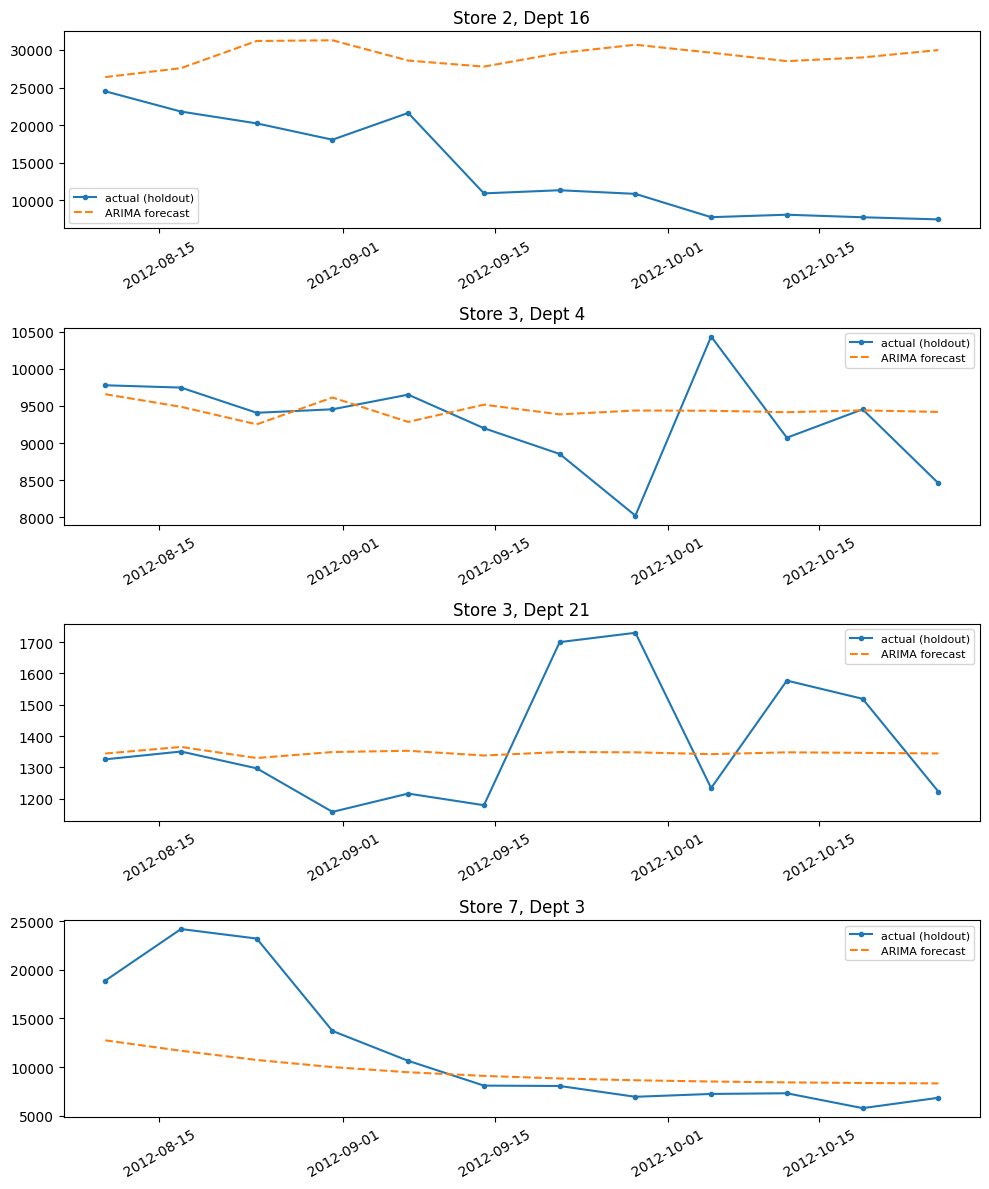

In [ ]:
ph = rep["pooled_holdout_predictions"]
groups = ph.groupby(["Store", "Dept"])
sample = list(groups.groups.keys())[:4]
fig, axes = plt.subplots(len(sample), 1, figsize=(10, 3 * len(sample)))
axes = np.atleast_1d(axes)
for ax, key in zip(axes, sample):
    sub = groups.get_group(key).sort_values("Date")
    ax.plot(sub["Date"], sub["actual"], marker="o", ms=3, label="actual (holdout)")
    ax.plot(sub["Date"], sub["prediction"], ls="--", label="ARIMA forecast")
    ax.set_title(f"Store {key[0]}, Dept {key[1]}"); ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

## 12. submission file

In [ ]:
if RUN_FULL_SUBMISSION:
    pipe = WalmartArimaPipeline()
    pipe._setup(merged_train[["Store", "Dept", "Date", "Weekly_Sales"]],
                {"order": list(FINAL_ORDER), "min_train_weeks": MIN_TRAIN_WEEKS,
                 "cap_factor": FORECAST_CAP_FACTOR})

    print(f"Forecasting the test set with order {FINAL_ORDER} (a few minutes)...", flush=True)
    preds = pipe.predict(None, test)
    assert len(preds) == len(test) and not np.isnan(preds).any()

    submission = pd.DataFrame({
        "Id": test["Store"].astype(str) + "_" + test["Dept"].astype(str) + "_" + test["Date"].astype(str),
        "Weekly_Sales": np.clip(preds, 0, None),
    })
    sub_path = DATA_DIR.parent / "submissions" / "submission_arima.csv"   # -> Drive
    sub_path.parent.mkdir(parents=True, exist_ok=True)
    submission.to_csv(sub_path, index=False)
    with mlflow.start_run(run_id=final_run_id):
        mlflow.log_artifact(str(sub_path))
    print("saved to Drive + logged to MLflow:", sub_path)
    display(submission.head())
else:
    print("RUN_FULL_SUBMISSION=False - skipping submission.")

Forecasting the test set with order (2, 1, 3) (a few minutes)...
🏃 View run ARIMA_Final__D_no_exog_wide_grid__order(2, 1, 3) at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/8/runs/5c32d48e50dd4b3ba76f9727beb0dcaf
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/8
saved to Drive + logged to MLflow: /content/drive/MyDrive/ML_FINAL_PROJECT/submissions/submission_arima.csv


,Id,Weekly_Sales
0,1_1_2012-11-02,25517.628092
1,1_1_2012-11-09,23167.047544
2,1_1_2012-11-16,22508.272153
3,1_1_2012-11-23,22313.169194
4,1_1_2012-11-30,22264.445357
